In [1]:
# ============================================================
# WEEK 9 PROJECT
# House Price Prediction using Machine Learning
# Author: Meda Venkata Lakshmi Divya
# Environment: Google Colab
# ============================================================

# ------------------------------------------------
# Cell 1: Upload Dataset
# ------------------------------------------------

from google.colab import files

uploaded = files.upload()

# Upload:
# house_prices(1).csv

Saving house_prices.csv to house_prices.csv


In [3]:
# ------------------------------------------------
# Cell 2: Import Required Libraries
# ------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
# ------------------------------------------------
# Cell 3: Load Dataset
# ------------------------------------------------

# Load dataset

df = pd.read_csv("house_prices.csv")

print("Dataset loaded successfully")

# Display first 5 rows
df.head()

Dataset loaded successfully


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [6]:
# ------------------------------------------------
# Cell 4: Explore Dataset
# ------------------------------------------------

print("Dataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(300, 8)

Dataset Columns:
Index(['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location',
       'Property_Type', 'Price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB
None

Missing Values:
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

Duplicate Rows:
0


In [7]:
# ------------------------------------------------
# Cell 5: Data Cleaning
# ------------------------------------------------

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Data cleaning completed successfully ✅")

Data cleaning completed successfully ✅


In [8]:
# ------------------------------------------------
# Cell 6: Encode Categorical Variables
# ------------------------------------------------

# Convert categorical columns into numerical format

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("Categorical variables encoded successfully")

df.head()

Categorical variables encoded successfully


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,0,3712,4,3,36,1,1,22260000
1,1,1591,4,1,35,2,1,16057500
2,2,1646,4,3,20,1,2,12730000
3,3,4814,1,2,13,0,2,50840000
4,4,800,4,2,38,2,0,10650000


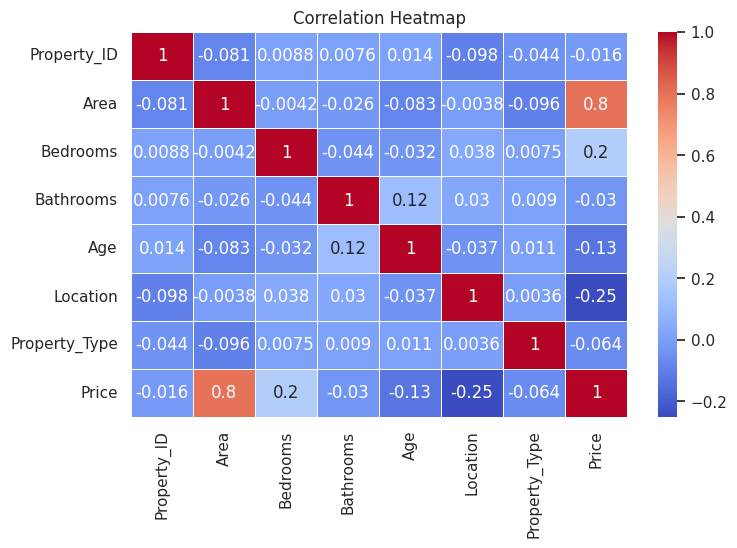

In [9]:
# ------------------------------------------------
# Cell 7: Correlation Heatmap
# ------------------------------------------------

plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
# ------------------------------------------------
# Cell 8: Feature Selection
# ------------------------------------------------

# Select input features and target variable

# Replace 'Price' below if your target column has another name

target_column = "Price"

X = df.drop(target_column, axis=1)
y = df[target_column]

print("Features and target selected successfully")

Features and target selected successfully


In [11]:
# ------------------------------------------------
# Cell 9: Train-Test Split
# ------------------------------------------------

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-test split completed successfully")

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Train-test split completed successfully
Training Data Shape: (240, 7)
Testing Data Shape : (60, 7)


In [12]:
# ------------------------------------------------
# Cell 10: Linear Regression Model
# ------------------------------------------------

# Create Linear Regression model

linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Make predictions
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [13]:
# ------------------------------------------------
# Cell 11: Evaluate Linear Regression Model
# ------------------------------------------------

# Calculate evaluation metrics

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("=" * 60)
print("LINEAR REGRESSION MODEL EVALUATION")
print("=" * 60)

print(f"MAE Score : {linear_mae:.2f}")
print(f"MSE Score : {linear_mse:.2f}")
print(f"R² Score  : {linear_r2:.2f}")

LINEAR REGRESSION MODEL EVALUATION
MAE Score : 5403119.90
MSE Score : 41900809994712.66
R² Score  : 0.71


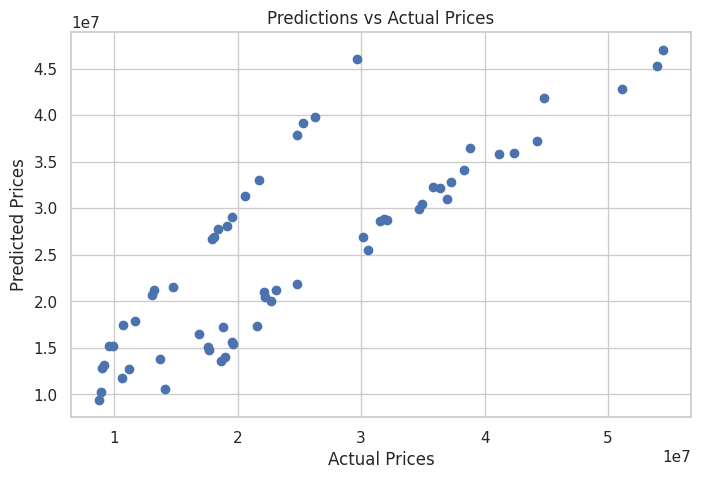

In [14]:
# ------------------------------------------------
# Cell 12: Predictions vs Actual Visualization
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    linear_predictions
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Predictions vs Actual Prices")

plt.show()

In [15]:
# ------------------------------------------------
# Cell 13: Polynomial Regression
# ------------------------------------------------

# Create polynomial features

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train polynomial regression model

poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)

poly_predictions = poly_model.predict(X_test_poly)

# Evaluate model

poly_r2 = r2_score(
    y_test,
    poly_predictions
)

print("Polynomial Regression R² Score:", poly_r2)

Polynomial Regression R² Score: 0.9577663914591792


In [16]:
# ------------------------------------------------
# Cell 14: Decision Tree Regressor
# ------------------------------------------------

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(X_test)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree R² Score:", tree_r2)

Decision Tree R² Score: 0.9440225753314806


In [17]:
# ------------------------------------------------
# Cell 15: Random Forest Regressor
# ------------------------------------------------

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

forest_predictions = forest_model.predict(X_test)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("Random Forest R² Score:", forest_r2)

Random Forest R² Score: 0.9670705462801117


In [18]:
# ------------------------------------------------
# Cell 16: Compare Model Performance
# ------------------------------------------------

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R² Score": [
        linear_r2,
        poly_r2,
        tree_r2,
        forest_r2
    ]
})

model_results

,Model,R² Score
0,Linear Regression,0.705790
1,Polynomial Regression,0.957766
2,Decision Tree,0.944023
3,Random Forest,0.967071


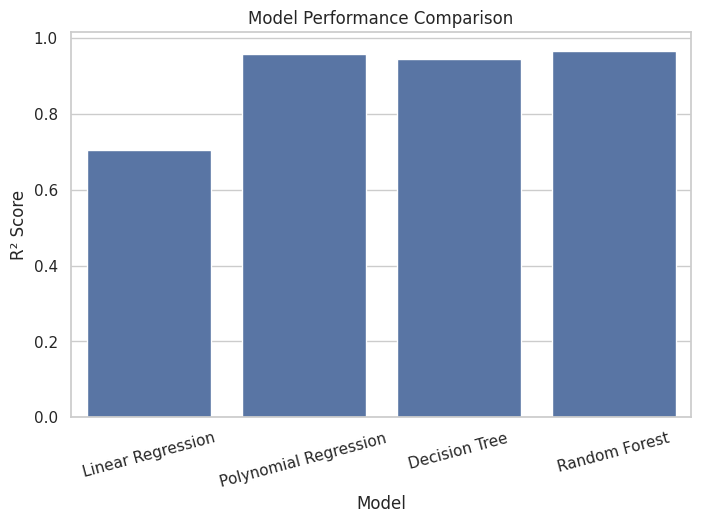

In [19]:
# ------------------------------------------------
# Cell 17: Visualize Model Comparison
# ------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="R² Score",
    data=model_results
)

plt.title("Model Performance Comparison")

plt.xticks(rotation=15)

plt.show()

In [20]:
# ------------------------------------------------
# Cell 18: Feature Importance
# ------------------------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Area,0.685569
5,Location,0.282871
2,Bedrooms,0.017595
4,Age,0.006420
0,Property_ID,0.004563
3,Bathrooms,0.001659
6,Property_Type,0.001323


In [21]:
# ------------------------------------------------
# Cell 19: Final Report
# ------------------------------------------------

best_model = model_results.sort_values(
    by="R² Score",
    ascending=False
).iloc[0]

print("=" * 70)
print("HOUSE PRICE PREDICTION MODEL REPORT")
print("=" * 70)

print(f"Best Model        : {best_model['Model']}")
print(f"Best R² Score     : {best_model['R² Score']:.2f}")

print("\nLinear Regression Metrics:")
print(f"MAE : {linear_mae:.2f}")
print(f"MSE : {linear_mse:.2f}")
print(f"R²  : {linear_r2:.2f}")

print("\nTop Important Features:")
print(importance.head())

print("=" * 70)

HOUSE PRICE PREDICTION MODEL REPORT
Best Model        : Random Forest
Best R² Score     : 0.97

Linear Regression Metrics:
MAE : 5403119.90
MSE : 41900809994712.66
R²  : 0.71

Top Important Features:
       Feature  Importance
1         Area    0.685569
5     Location    0.282871
2     Bedrooms    0.017595
4          Age    0.006420
0  Property_ID    0.004563
